# Compositional Generalization in Linear Networks

In [1]:
%matplotlib widget

In [2]:
import jax
import jax.numpy as jnp
import numpy as np

from task import generate_brownian_tree
from network import init_shallow, init_deep
from network_aux import loss_fn
from train import train
from plotting import plot_data_kernels, plot_loss_curves, plot_shallow_kernels, plot_deep_kernels, plot_effective_svd

# Config
BRANCHING = (2, 3, 4)
D = 256       # observation dimension
N = 256      # hidden width
KAPPA0 = 1e-1 # inverse temperature (prior / data balance)
DS = 1e-3     # discretization step size
S_MAX = 10000.0  # continuous training time (max_steps = s_max / ds)
DEPTH = 3     # depth for deep network
MUP = True   # toggle maximal update parametrization
NTP = True    # neural tangent parameterization
SIGMA = 0.8   # O(1) scalar premultiplying init scale
COSSIM = True # kernel metric: True=cosine similarity, False=dot product

In [3]:
# Generate train and test datasets (shared root, different lower-level noise)
SHARED_DEPTH = 1

X_train, Y_train, paths_train = generate_brownian_tree(
    branching=BRANCHING, dim=D, seed_prefix=(0,), shared_depth=SHARED_DEPTH,
)
X_test, Y_test, paths_test = generate_brownian_tree(
    branching=BRANCHING, dim=D, seed_prefix=(1,), shared_depth=SHARED_DEPTH,
)

print(f"Train: X {X_train.shape}, Y {Y_train.shape}")
print(f"Test:  X {X_test.shape}, Y {Y_test.shape}")
print(f"Leaves per root branch: {[int((Y_train.argmax(1) == i).sum()) for i in range(BRANCHING[0])]}")

Train: X (24, 256), Y (24, 2)
Test:  X (24, 256), Y (24, 2)
Leaves per root branch: [12, 12]


Train paths: [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0)] ...
Test paths:  [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0)] ...


E0401 22:09:06.333706 4166744 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[24,24]{1,0} fusion(a.1, b.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["64","16"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0401 22:09:06.333798 4166744 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[24,256]{1,0} parameter(0)
  parameter_1 = f32[256,24]{1,0} parameter(1)
  ROOT dot_general.0 = f32[24,24]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["128"]}
}
E0401 22:09:06.342102 4166742 xtile_compiler.cc:399

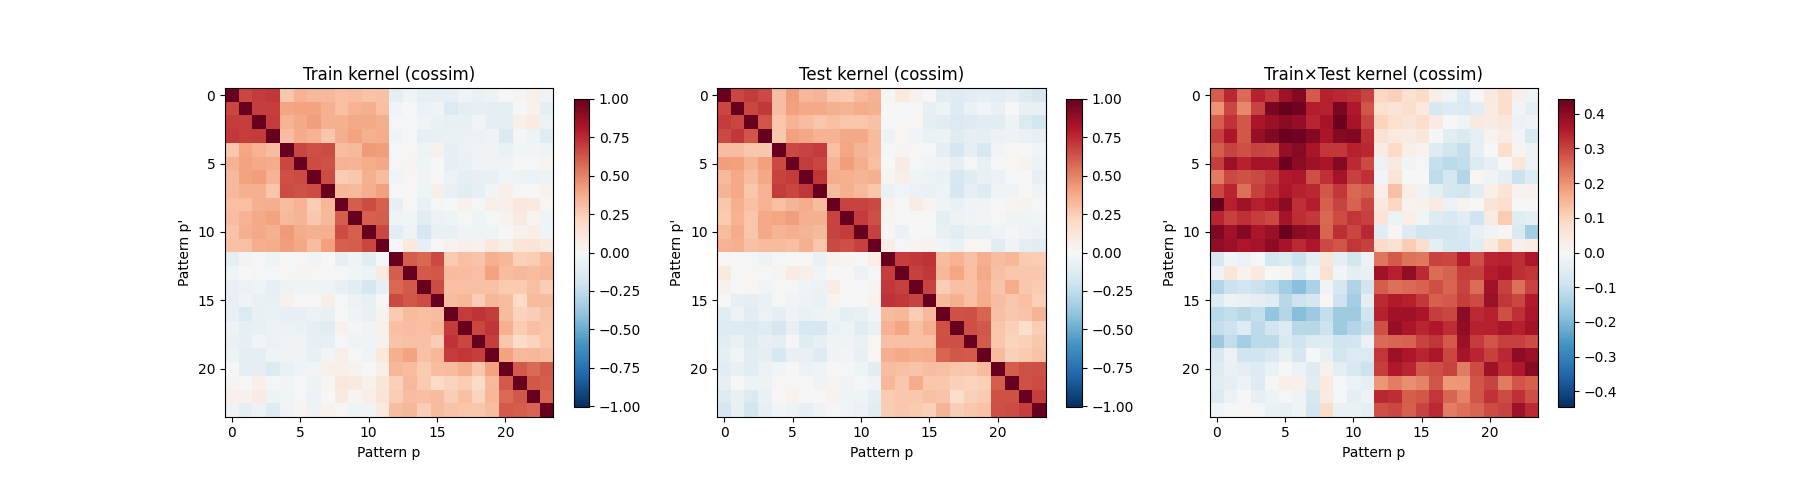

In [4]:
# Data is already in depth-first (ultrametric) order from generation
print(f"Train paths: {paths_train[:5]} ...")
print(f"Test paths:  {paths_test[:5]} ...")

X_tr, Y_tr = jnp.array(X_train), jnp.array(Y_train)
X_te, Y_te = jnp.array(X_test), jnp.array(Y_test)

_ = plot_data_kernels(X_train, X_test, cossim=COSSIM)

In [5]:
# Initialize networks
key = jax.random.key(0)
k1, k2 = jax.random.split(key)

d_out = BRANCHING[0]
params_shallow = init_shallow(k1, D, d_out, sigma=SIGMA)
params_deep = init_deep(k2, D, d_out, width=N, depth=DEPTH, sigma=SIGMA)

print(f"Shallow: {[w.shape for w in params_shallow]}")
print(f"Deep:    {[w.shape for w in params_deep]}")
print(f"muP: {MUP}, NTP: {NTP}, sigma: {SIGMA}")

Shallow: [(2, 256)]
Deep:    [(256, 256), (256, 256), (2, 256)]
muP: True, NTP: True, sigma: 0.8


In [6]:
# Train both networks on train split
shared_config = dict(branching=BRANCHING, D=D, N=N, depth=DEPTH, sigma=SIGMA)

print("=== Shallow ===")
params_shallow_trained, curves_shallow = train(
    params_shallow, X_tr, Y_tr, kappa0=KAPPA0, ds=DS, s_max=S_MAX, sigma=SIGMA,
    x_test=X_te, y_test=Y_te, mup=MUP, ntp=NTP, cossim=COSSIM,
    run_name="shallow", config={"arch": "shallow", **shared_config},
)

print("\n=== Deep ===")
params_deep_trained, curves_deep = train(
    params_deep, X_tr, Y_tr, kappa0=KAPPA0, ds=DS, s_max=S_MAX, sigma=SIGMA,
    x_test=X_te, y_test=Y_te, mup=MUP, ntp=NTP, cossim=COSSIM,
    run_name=f"deep-{DEPTH}", config={"arch": "deep", **shared_config},
)

print(f"\nShallow test MSE: {curves_shallow['mse_test'][-1]:.6f}")
print(f"Deep    test MSE: {curves_deep['mse_test'][-1]:.6f}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /nfs/nhome/live/jbauer/.netrc.


=== Shallow ===


wandb: Currently logged in as: japhba (japhba-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Training with ds=1.00e-03, s_max=10000.0, eta=2.08e-06, max_steps=10000000 | x: {CudaDevice(id=0)}, y: {CudaDevice(id=0)}, params: {'W0': {CudaDevice(id=0)}}


Training:   0%|          | 0.00/10000.00s [00:00<?, ?s/s]

...

Training with ds=1.00e-03, s_max=10000.0, eta=2.08e-06, max_steps=10000000 | x: {CudaDevice(id=0)}, y: {CudaDevice(id=0)}, params: {'W0': {CudaDevice(id=0)}, 'W1': {CudaDevice(id=0)}, 'W2': {CudaDevice(id=0)}}


Training:   0%|          | 0.00/10000.00s [00:00<?, ?s/s]

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


ema_loss,██▇▆▅▃▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
log_mse,▂▂▁▁▂▂▃▃▄▅▇█████████████████████████████
log_mse_test,███▇▇▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
log_nll,█▇▇▇▇▆▆▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss,█▆▆▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse,▁▁▁▁▁▁▂▂▅▅▆▇▇▇▇█████████████████████████
mse_test,█▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
nll_prior,█▇▇▄▄▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
s,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
slope,██▆▅▅▅▄▂▂▂▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▆▆▆▆▇▇▇▇███████
+2,...



Shallow test MSE: 0.052169
Deep    test MSE: 0.052885


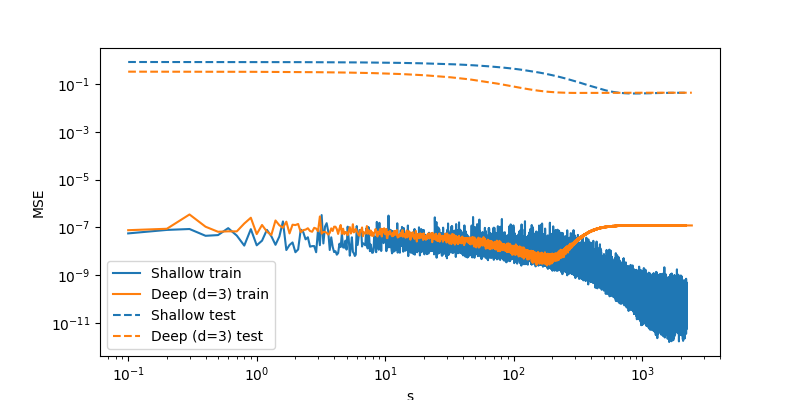

In [ ]:
_ = plot_loss_curves(curves_shallow, curves_deep, DEPTH)

In [ ]:
_ = plot_shallow_kernels(params_shallow_trained, X_tr, X_te, mup=MUP, ntp=NTP, cossim=COSSIM)

In [ ]:
_ = plot_deep_kernels(params_deep_trained, X_tr, X_te, mup=MUP, ntp=NTP, cossim=COSSIM)

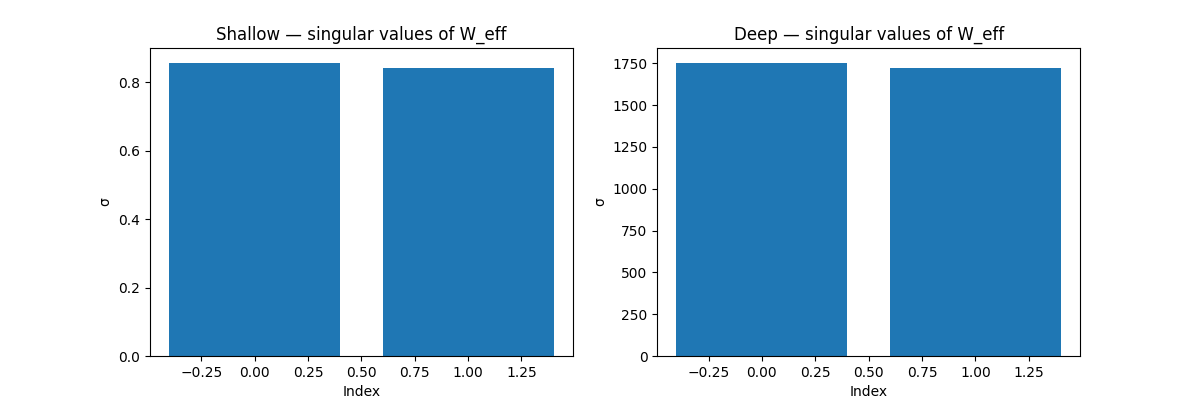

In [ ]:
_ = plot_effective_svd(params_shallow_trained, params_deep_trained)